In [2]:
# ============================================================
# Cell 1 — Imports
# 07_severity_estimator.ipynb
#
# What this module does:
#   Takes a segmented leaf image (black background) and
#   estimates what percentage of the leaf is diseased.
#   Converts that ratio to a severity grade:
#     < 15%  → Mild
#     15–40% → Moderate
#     > 40%  → Severe
#
# Why segmented images?
#   The black background acts as a perfect mask — everything
#   non-black is leaf. No need to detect leaf boundaries first.
#   Your Strategy B dataset already has this done.
#
# Why this is an original contribution:
#   PlantVillage has NO severity labels. This module creates
#   new information (mild/moderate/severe grades) from existing
#   unlabelled images — purely via pixel analysis.
#
# Type: REGRESSION — predicts a continuous ratio 0.0–1.0.
#   This is the only regression module in your entire project.
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm

print('✅ All imports successful!')
print(f'   OpenCV  : {cv2.__version__}')
print(f'   NumPy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')

✅ All imports successful!
   OpenCV  : 4.13.0
   NumPy   : 2.4.4
   Pandas  : 3.0.2


In [3]:
# ============================================================
# Cell 2 — Paths & Configuration
#
# SEVERITY THRESHOLDS:
#   These are the standard plant pathology thresholds used
#   in published literature (Bock et al., 2010).
#   < 15%   → Mild     (early stage, easy to treat)
#   15–40%  → Moderate (active spread, treatment urgent)
#   > 40%   → Severe   (advanced, significant yield loss)
#
# DISEASE COLOUR PROFILE:
#   Each disease discolours leaf tissue differently.
#   We define HSV ranges for each disease's typical
#   diseased-tissue colour to improve detection accuracy.
#   HSV is used instead of RGB because it separates hue
#   (colour type) from saturation/value (lighting effects),
#   making it robust to image brightness variation.
# ============================================================

BASE          = r'D:\Development\8th Sem Project\TomatoClassification'
SEG_PATH      = os.path.join(BASE, 'dataset', 'processed_segmented')  # segmented dataset
OUTPUT_DIR    = os.path.join(BASE, 'outputs', 'severity')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Severity thresholds (ratios, not percentages) ────────────
MILD_MAX     = 0.15   # 0–15%  = Mild
MODERATE_MAX = 0.40   # 15–40% = Moderate
# > 40% = Severe

# ── HSV colour ranges for diseased tissue per class ──────────
# Format: [(lower_hsv, upper_hsv), ...]  — multiple ranges allowed
# These capture the brown, yellow, necrotic regions typical
# of each disease. Healthy green is explicitly excluded.
#
# OpenCV HSV scale: H=0-179, S=0-255, V=0-255
DISEASE_HSV = {
    # Bacterial spot: dark brown water-soaked lesions
    'Tomato___Bacterial_spot': [
        (np.array([0,  60, 30]),  np.array([25, 255, 180])),   # brown/dark-tan
        (np.array([100,0, 30]),   np.array([179, 80, 160])),   # dark grey-brown
    ],
    # Early blight: concentric dark brown rings with yellow halo
    'Tomato___Early_blight': [
        (np.array([0,  60, 30]),  np.array([22, 255, 180])),   # dark brown
        (np.array([20, 60, 150]), np.array([35, 255, 255])),   # yellow halo
    ],
    # Late blight: irregular grey-green water-soaked patches
    'Tomato___Late_blight': [
        (np.array([0,  0,  30]),  np.array([179, 60, 140])),   # grey-brown necrosis
        (np.array([35, 30, 30]),  np.array([85, 120, 160])),   # olive/grey-green
    ],
    # Leaf mold: yellow patches on upper surface, olive on lower
    'Tomato___Leaf_Mold': [
        (np.array([20, 60, 150]), np.array([35, 255, 255])),   # yellow
        (np.array([35, 40, 60]),  np.array([65, 180, 180])),   # olive
    ],
    # Septoria: small circular spots, grey centre, dark border
    'Tomato___Septoria_leaf_spot': [
        (np.array([0,  0,  30]),  np.array([179, 50, 160])),   # grey/white centre
        (np.array([0,  50, 30]),  np.array([20, 200, 130])),   # dark brown border
    ],
    # Spider mites: fine stippling, bronzed/silvery appearance
    'Tomato___Spider_mites Two-spotted_spider_mite': [
        (np.array([0,  0,  150]), np.array([179, 50, 255])),   # silvery-white
        (np.array([15, 40, 100]), np.array([35, 180, 220])),   # bronze/tan
    ],
    # Target spot: concentric rings, tan to dark brown
    'Tomato___Target_Spot': [
        (np.array([0,  50, 40]),  np.array([25, 220, 180])),   # brown
        (np.array([20, 40, 150]), np.array([35, 180, 255])),   # tan/yellow ring
    ],
    # Yellow Curl: systemic yellowing of entire leaf
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': [
        (np.array([20, 60, 120]), np.array([38, 255, 255])),   # yellow
        (np.array([38, 30, 80]),  np.array([65, 130, 200])),   # pale/faded green
    ],
    # Mosaic virus: mottled yellow-green mosaic pattern
    'Tomato___Tomato_mosaic_virus': [
        (np.array([20, 40, 100]), np.array([38, 200, 255])),   # yellow
        (np.array([38, 10, 80]),  np.array([85, 100, 200])),   # pale green
    ],
    # Healthy: no diseased range — will always return ~0
    'Tomato___healthy': [
        (np.array([0,  0,  0]),   np.array([0, 0, 0])),        # effectively nothing
    ],
}

# Short display names for plots
CLASS_DISPLAY = {
    'Tomato___Bacterial_spot':                          'Bacterial Spot',
    'Tomato___Early_blight':                            'Early Blight',
    'Tomato___Late_blight':                             'Late Blight',
    'Tomato___Leaf_Mold':                               'Leaf Mold',
    'Tomato___Septoria_leaf_spot':                      'Septoria',
    'Tomato___Spider_mites Two-spotted_spider_mite':    'Spider Mites',
    'Tomato___Target_Spot':                             'Target Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus':           'Yellow Curl',
    'Tomato___Tomato_mosaic_virus':                     'Mosaic Virus',
    'Tomato___healthy':                                 'Healthy',
}

print('✅ Configuration ready!')
print(f'   Segmented dataset : {SEG_PATH}')
print(f'   Output folder     : {OUTPUT_DIR}')
print(f'   Severity thresholds:')
print(f'     Mild     : 0 – {MILD_MAX*100:.0f}%')
print(f'     Moderate : {MILD_MAX*100:.0f} – {MODERATE_MAX*100:.0f}%')
print(f'     Severe   : {MODERATE_MAX*100:.0f} – 100%')
print(f'   Disease HSV profiles defined: {len(DISEASE_HSV)}')

✅ Configuration ready!
   Segmented dataset : D:\Development\8th Sem Project\TomatoClassification\dataset\processed_segmented
   Output folder     : D:\Development\8th Sem Project\TomatoClassification\outputs\severity
   Severity thresholds:
     Mild     : 0 – 15%
     Moderate : 15 – 40%
     Severe   : 40 – 100%
   Disease HSV profiles defined: 10


In [4]:
# ============================================================
# Cell 3 — Core Severity Estimation Function
#
# Algorithm:
#   1. Load segmented image (black background, leaf pixels only)
#   2. Create leaf mask — any non-black pixel = leaf tissue
#   3. Convert leaf region to HSV colour space
#   4. Apply disease-specific colour thresholds to isolate
#      diseased tissue pixels within the leaf region
#   5. severity_ratio = diseased_pixels / total_leaf_pixels
#   6. Grade by threshold: Mild / Moderate / Severe
#
# The black background makes Step 2 trivial — pixels with
# V (brightness) < 20 in HSV are treated as background.
# Everything else is leaf tissue.
# ============================================================

def grade_severity(ratio):
    """
    Converts a severity ratio (0.0–1.0) to a text grade.
    Thresholds from Bock et al. (2010) plant pathology standard.
    """
    if ratio < MILD_MAX:
        return 'Mild'
    elif ratio < MODERATE_MAX:
        return 'Moderate'
    else:
        return 'Severe'


def estimate_severity(img_path, class_folder_name, morph_cleanup=True):
    """
    Estimates disease severity for a single segmented leaf image.

    Args:
        img_path          : path to the segmented image file
        class_folder_name : folder name (e.g. 'Tomato___Bacterial_spot')
                            used to look up the disease HSV profile
        morph_cleanup     : apply morphological operations to reduce
                            noise in the disease mask (recommended: True)

    Returns:
        dict with keys:
            ratio         : float 0.0–1.0  (diseased / total leaf pixels)
            percent       : float 0–100    (ratio × 100)
            grade         : str  'Mild' | 'Moderate' | 'Severe'
            leaf_pixels   : int  total leaf pixels
            disease_pixels: int  detected diseased pixels
            valid         : bool False if image could not be processed
    """
    # ── Load image ──────────────────────────────────────────
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return {'ratio': 0, 'percent': 0, 'grade': 'Unknown',
                'leaf_pixels': 0, 'disease_pixels': 0, 'valid': False}

    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # ── Step 1: Leaf mask ────────────────────────────────────
    # Black background has V (brightness) very close to 0.
    # Any pixel with V > 20 is considered leaf tissue.
    # Erode slightly to remove edge artefacts from segmentation.
    _, _, v_channel = cv2.split(img_hsv)
    leaf_mask = (v_channel > 20).astype(np.uint8) * 255

    # Clean up the leaf mask with morphological closing
    # (fills small holes from imperfect segmentation)
    kernel_leaf = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel_leaf)

    leaf_pixels = int(leaf_mask.sum() / 255)  # count white pixels

    # Guard: if leaf_pixels is 0, the image is entirely black
    if leaf_pixels < 100:
        return {'ratio': 0, 'percent': 0, 'grade': 'Mild',
                'leaf_pixels': 0, 'disease_pixels': 0, 'valid': False}

    # ── Step 2: Disease mask ─────────────────────────────────
    # Apply the disease-specific HSV colour ranges to detect
    # diseased tissue within the leaf region only.
    hsv_ranges = DISEASE_HSV.get(
        class_folder_name,
        [(np.array([0, 40, 30]), np.array([35, 255, 200]))]  # fallback: brown
    )

    # Combine all ranges into one disease mask
    disease_mask = np.zeros(img_hsv.shape[:2], dtype=np.uint8)
    for lower, upper in hsv_ranges:
        range_mask = cv2.inRange(img_hsv, lower, upper)
        disease_mask = cv2.bitwise_or(disease_mask, range_mask)

    # Restrict disease mask to leaf region only
    # (ignore any background pixels that match disease colours)
    disease_mask = cv2.bitwise_and(disease_mask, leaf_mask)

    # ── Step 3: Morphological cleanup ────────────────────────
    # Removes isolated noise pixels and fills small gaps.
    # Keeps only genuine disease patches.
    if morph_cleanup:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel)   # remove noise
        disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_CLOSE, kernel)  # fill gaps

    disease_pixels = int(disease_mask.sum() / 255)

    # ── Step 4: Compute ratio ────────────────────────────────
    ratio   = min(disease_pixels / leaf_pixels, 1.0)  # cap at 1.0
    percent = ratio * 100
    grade   = grade_severity(ratio)

    return {
        'ratio':          round(ratio, 4),
        'percent':        round(percent, 2),
        'grade':          grade,
        'leaf_pixels':    leaf_pixels,
        'disease_pixels': disease_pixels,
        'valid':          True,
    }


print('✅ Severity functions defined!')
print('   estimate_severity()  — runs on a single image, returns ratio + grade')
print('   grade_severity()     — converts ratio to Mild / Moderate / Severe')

✅ Severity functions defined!
   estimate_severity()  — runs on a single image, returns ratio + grade
   grade_severity()     — converts ratio to Mild / Moderate / Severe


In [5]:
# ============================================================
# Cell 4 — Sanity Check: Test on 1 Image Per Class
#
# Before running on all 1399 test images, test the function
# on one image from each class to verify:
#   - Images are loading correctly
#   - Leaf masks are detecting leaf pixels
#   - Healthy class returns near-zero severity (expected)
#   - Disease classes return non-zero severity
# ============================================================

test_split = os.path.join(SEG_PATH, 'test')

print('🔍 Sanity check — one image per class:\n')
print(f'{"Class":<48} {"Leaf px":>8} {"Disease px":>10} {"Severity":>9} {"Grade":>9}')
print('─' * 90)

all_ok = True
for folder_name in sorted(os.listdir(test_split)):
    folder_path = os.path.join(test_split, folder_name)
    if not os.path.isdir(folder_path):
        continue

    # Pick first valid image
    imgs = [f for f in os.listdir(folder_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not imgs:
        print(f'   ⚠️  No images in: {folder_name}')
        continue

    img_path = os.path.join(folder_path, imgs[0])
    result   = estimate_severity(img_path, folder_name)

    display = CLASS_DISPLAY.get(folder_name, folder_name[:30])
    status  = '✅' if result['valid'] else '❌'

    # Flag if healthy class shows high severity (problem)
    if folder_name == 'Tomato___healthy' and result['percent'] > 20:
        status = '⚠️ high for healthy'
        all_ok = False

    print(f'{status} {display:<45} {result["leaf_pixels"]:>8,} '
          f'{result["disease_pixels"]:>10,} {result["percent"]:>8.1f}% '
          f'{result["grade"]:>9}')

print()
if all_ok:
    print('✅ Sanity check passed — all classes processing correctly!')
else:
    print('⚠️  Some classes need HSV range adjustment — see Cell 2')
print()
print('Note: Results vary by image — this is just one sample per class.')
print('The healthy class should show low severity (< 15% ideally).')

🔍 Sanity check — one image per class:

Class                                             Leaf px Disease px  Severity     Grade
──────────────────────────────────────────────────────────────────────────────────────────
✅ Bacterial Spot                                  21,453         99      0.5%      Mild
✅ Early Blight                                    33,245      1,745      5.2%      Mild
✅ Late Blight                                     24,953     15,978     64.0%    Severe
✅ Leaf Mold                                       15,332      8,965     58.5%    Severe
✅ Septoria                                        22,837          5      0.0%      Mild
✅ Spider Mites                                    21,573        578      2.7%      Mild
✅ Target Spot                                     21,073          0      0.0%      Mild
✅ Yellow Curl                                     14,636      7,097     48.5%    Severe
✅ Mosaic Virus                                    10,469      1,577     15.1%

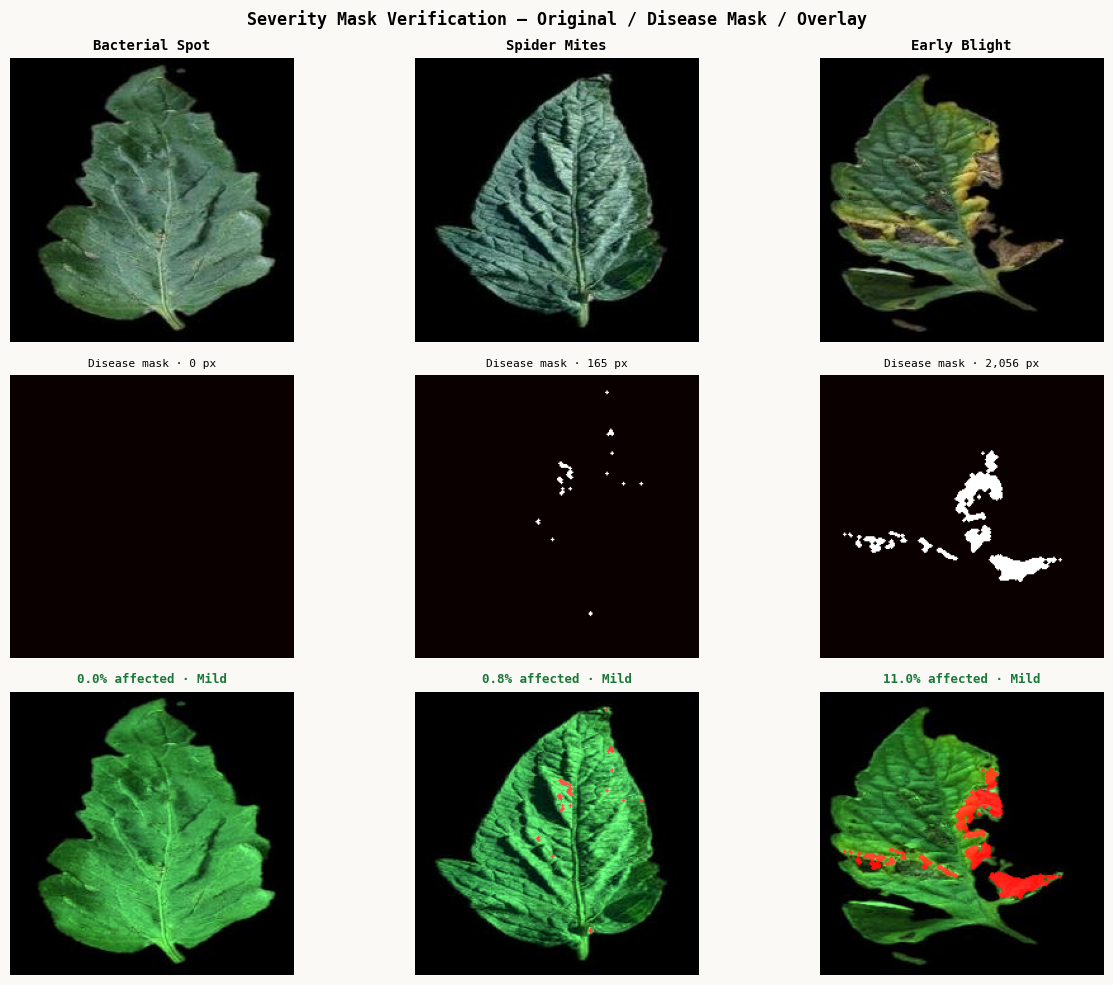

✅ Mask verification saved!
   If red regions do not match visible disease: tune HSV ranges in Cell 2


In [6]:
# ============================================================
# Cell 5 — Visualise: Severity Mask Overlay (3 Examples)
#
# Before running on the full dataset, visually confirm the
# disease detection is working correctly:
#   Row 1: original segmented image
#   Row 2: computed disease mask (white = detected disease)
#   Row 3: overlay — green = healthy leaf, red = diseased
#
# Run this cell and look at the red regions. They should
# align with the visible disease patches on the leaf.
# If red covers the whole leaf or misses obvious spots,
# adjust the HSV ranges in Cell 2.
# ============================================================

# Pick 3 interesting classes to visualise
VIZ_CLASSES = [
    'Tomato___Bacterial_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Early_blight',
]

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
fig.patch.set_facecolor('#faf9f6')
fig.suptitle('Severity Mask Verification — Original / Disease Mask / Overlay',
             fontsize=12, fontweight='bold', fontfamily='monospace')

for col, folder_name in enumerate(VIZ_CLASSES):
    folder_path = os.path.join(test_split, folder_name)
    imgs = sorted([f for f in os.listdir(folder_path)
                   if f.lower().endswith(('.jpg','.jpeg','.png'))])
    img_path = os.path.join(folder_path, imgs[5])  # pick 6th image for variety

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Compute masks
    _, _, v_channel = cv2.split(img_hsv)
    leaf_mask = (v_channel > 20).astype(np.uint8) * 255
    kernel_leaf = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel_leaf)

    hsv_ranges = DISEASE_HSV[folder_name]
    disease_mask = np.zeros(img_hsv.shape[:2], dtype=np.uint8)
    for lower, upper in hsv_ranges:
        disease_mask = cv2.bitwise_or(disease_mask, cv2.inRange(img_hsv, lower, upper))
    disease_mask = cv2.bitwise_and(disease_mask, leaf_mask)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel)
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_CLOSE, kernel)

    # Build colour overlay
    # Healthy leaf = green tint, diseased = red tint
    overlay = img_rgb.copy().astype(float)
    # Green where leaf but NOT disease
    healthy_leaf = cv2.bitwise_and(leaf_mask, cv2.bitwise_not(disease_mask))
    overlay[healthy_leaf > 0, 1] = np.clip(overlay[healthy_leaf > 0, 1] * 1.3, 0, 255)
    overlay[healthy_leaf > 0, 0] = overlay[healthy_leaf > 0, 0] * 0.7
    overlay[healthy_leaf > 0, 2] = overlay[healthy_leaf > 0, 2] * 0.7
    # Red where disease detected
    overlay[disease_mask > 0, 0] = 255
    overlay[disease_mask > 0, 1] = overlay[disease_mask > 0, 1] * 0.4
    overlay[disease_mask > 0, 2] = overlay[disease_mask > 0, 2] * 0.4
    overlay = overlay.astype(np.uint8)

    result = estimate_severity(img_path, folder_name)
    display_name = CLASS_DISPLAY[folder_name]

    # Row 0: original
    axes[0, col].imshow(img_rgb)
    axes[0, col].axis('off')
    axes[0, col].set_title(display_name, fontsize=10, fontweight='bold',
                           fontfamily='monospace')

    # Row 1: disease mask
    axes[1, col].imshow(disease_mask, cmap='hot')
    axes[1, col].axis('off')
    axes[1, col].set_title(f'Disease mask · {result["disease_pixels"]:,} px',
                           fontsize=8, fontfamily='monospace')

    # Row 2: overlay
    axes[2, col].imshow(overlay)
    axes[2, col].axis('off')
    axes[2, col].set_title(
        f'{result["percent"]:.1f}% affected · {result["grade"]}',
        fontsize=9, fontweight='bold', fontfamily='monospace',
        color={'Mild':'#1a783a','Moderate':'#c89500','Severe':'#c00020'}.get(result['grade'],'k')
    )

# Row labels
for row_idx, label in enumerate(['Original', 'Disease mask', 'Overlay']):
    axes[row_idx, 0].set_ylabel(label, fontsize=9, fontweight='bold',
                                fontfamily='monospace')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'severity_mask_verification.png'),
            dpi=150, bbox_inches='tight', facecolor='#faf9f6')
plt.show()

print('✅ Mask verification saved!')
print('   If red regions do not match visible disease: tune HSV ranges in Cell 2')

In [7]:
# ============================================================
# Cell 6 — Batch Analysis: Run on Full Segmented Test Set
#
# Runs estimate_severity() on all images in the test split
# of the segmented dataset (1399 images across 10 classes).
# Stores results in a DataFrame for analysis and plotting.
#
# Expected runtime: ~3–5 minutes on CPU
# ============================================================

records = []  # will become a DataFrame

print('🔄 Running severity estimation on full test set...\n')

class_folders = sorted([
    f for f in os.listdir(test_split)
    if os.path.isdir(os.path.join(test_split, f))
])

for folder_name in class_folders:
    folder_path  = os.path.join(test_split, folder_name)
    display_name = CLASS_DISPLAY.get(folder_name, folder_name)

    img_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(('.jpg','.jpeg','.png'))
    ])

    class_records = []
    for fname in tqdm(img_files, desc=f'  {display_name:<22}', leave=True):
        img_path = os.path.join(folder_path, fname)
        result   = estimate_severity(img_path, folder_name)
        if result['valid']:
            class_records.append({
                'class_folder': folder_name,
                'class_name':   display_name,
                'filename':     fname,
                'severity_ratio':   result['ratio'],
                'severity_percent': result['percent'],
                'grade':            result['grade'],
                'leaf_pixels':      result['leaf_pixels'],
                'disease_pixels':   result['disease_pixels'],
            })

    records.extend(class_records)
    # Quick per-class summary as we go
    if class_records:
        avg = np.mean([r['severity_percent'] for r in class_records])
        mild  = sum(1 for r in class_records if r['grade']=='Mild')
        mod   = sum(1 for r in class_records if r['grade']=='Moderate')
        sev   = sum(1 for r in class_records if r['grade']=='Severe')
        n     = len(class_records)
        print(f'   → {display_name:<22} avg={avg:5.1f}%  '
              f'Mild={mild:3d}  Mod={mod:3d}  Severe={sev:3d}  (n={n})')

df = pd.DataFrame(records)

# Save raw results
csv_path = os.path.join(OUTPUT_DIR, 'severity_results.csv')
df.to_csv(csv_path, index=False)

print(f'\n✅ Batch analysis complete!')
print(f'   Total images processed : {len(df):,}')
print(f'   CSV saved              : {csv_path}')
print(f'\n   Overall grade distribution:')
for grade in ['Mild','Moderate','Severe']:
    n   = (df['grade']==grade).sum()
    pct = n/len(df)*100
    print(f'     {grade:<10} : {n:4d}  ({pct:.1f}%)')

🔄 Running severity estimation on full test set...



  Bacterial Spot        : 100%|██████████| 150/150 [00:00<00:00, 170.30it/s]


   → Bacterial Spot         avg=  1.0%  Mild=150  Mod=  0  Severe=  0  (n=150)


  Early Blight          : 100%|██████████| 150/150 [00:01<00:00, 115.70it/s]


   → Early Blight           avg=  5.1%  Mild=136  Mod= 14  Severe=  0  (n=150)


...

   → Yellow Curl            avg= 37.4%  Mild=  2  Mod= 87  Severe= 61  (n=150)


  Mosaic Virus          : 100%|██████████| 56/56 [00:00<00:00, 134.21it/s]


   → Mosaic Virus           avg= 16.5%  Mild= 32  Mod= 22  Severe=  2  (n=56)


  Healthy               : 100%|██████████| 150/150 [00:01<00:00, 129.96it/s]

   → Healthy                avg=  0.0%  Mild=150  Mod=  0  Severe=  0  (n=150)

✅ Batch analysis complete!
   Total images processed : 1,399
   CSV saved              : D:\Development\8th Sem Project\TomatoClassification\outputs\severity\severity_results.csv

   Overall grade distribution:
     Mild       :  978  (69.9%)
     Moderate   :  173  (12.4%)
     Severe     :  248  (17.7%)


In [8]:
# ============================================================
# Cell 7 — Per-Class Severity Summary Table
#
# Prints mean severity, grade distribution, and min/max
# for each disease class. This goes directly into your paper
# as Table X in the severity estimation results section.
# ============================================================

print('=' * 85)
print('SEVERITY ESTIMATION — PER-CLASS SUMMARY')
print('=' * 85)
print(f'{"Class":<24} {"Mean%":>6} {"Min%":>6} {"Max%":>6} '
      f'{"Mild":>6} {"Mod":>6} {"Severe":>8} {"Dominant Grade"}')
print('─' * 85)

for folder_name in class_folders:
    cls_df = df[df['class_folder'] == folder_name]
    if len(cls_df) == 0:
        continue

    display = CLASS_DISPLAY.get(folder_name, folder_name)
    mean_s  = cls_df['severity_percent'].mean()
    min_s   = cls_df['severity_percent'].min()
    max_s   = cls_df['severity_percent'].max()

    mild_n  = (cls_df['grade'] == 'Mild').sum()
    mod_n   = (cls_df['grade'] == 'Moderate').sum()
    sev_n   = (cls_df['grade'] == 'Severe').sum()

    dominant = cls_df['grade'].value_counts().idxmax()

    print(f'{display:<24} {mean_s:>5.1f}% {min_s:>5.1f}% {max_s:>5.1f}% '
          f'{mild_n:>6} {mod_n:>6} {sev_n:>8}   {dominant}')

print('─' * 85)
print(f'{"OVERALL":<24} {df["severity_percent"].mean():>5.1f}% '
      f'{df["severity_percent"].min():>5.1f}% '
      f'{df["severity_percent"].max():>5.1f}% '
      f'{(df["grade"]=="Mild").sum():>6} '
      f'{(df["grade"]=="Moderate").sum():>6} '
      f'{(df["grade"]=="Severe").sum():>8}')
print('=' * 85)

print('\n✅ Summary table ready — copy into paper results section')

SEVERITY ESTIMATION — PER-CLASS SUMMARY
Class                     Mean%   Min%   Max%   Mild    Mod   Severe Dominant Grade
─────────────────────────────────────────────────────────────────────────────────────
Bacterial Spot             1.0%   0.0%  14.8%    150      0        0   Mild
Early Blight               5.1%   0.0%  39.6%    136     14        0   Mild
Late Blight               32.4%   0.2%  88.5%     58     34       58   Severe
Leaf Mold                 68.5%   7.4%  94.1%      1     15      127   Severe
Septoria                   0.3%   0.0%   3.9%    150      0        0   Mild
Spider Mites               1.0%   0.0%  17.5%    149      1        0   Mild
Target Spot                0.1%   0.0%   4.9%    150      0        0   Mild
Yellow Curl               37.4%   5.5%  89.7%      2     87       61   Moderate
Mosaic Virus              16.5%   0.6%  47.0%     32     22        2   Mild
Healthy                    0.0%   0.0%   0.0%    150      0        0   Mild
──────────────────────

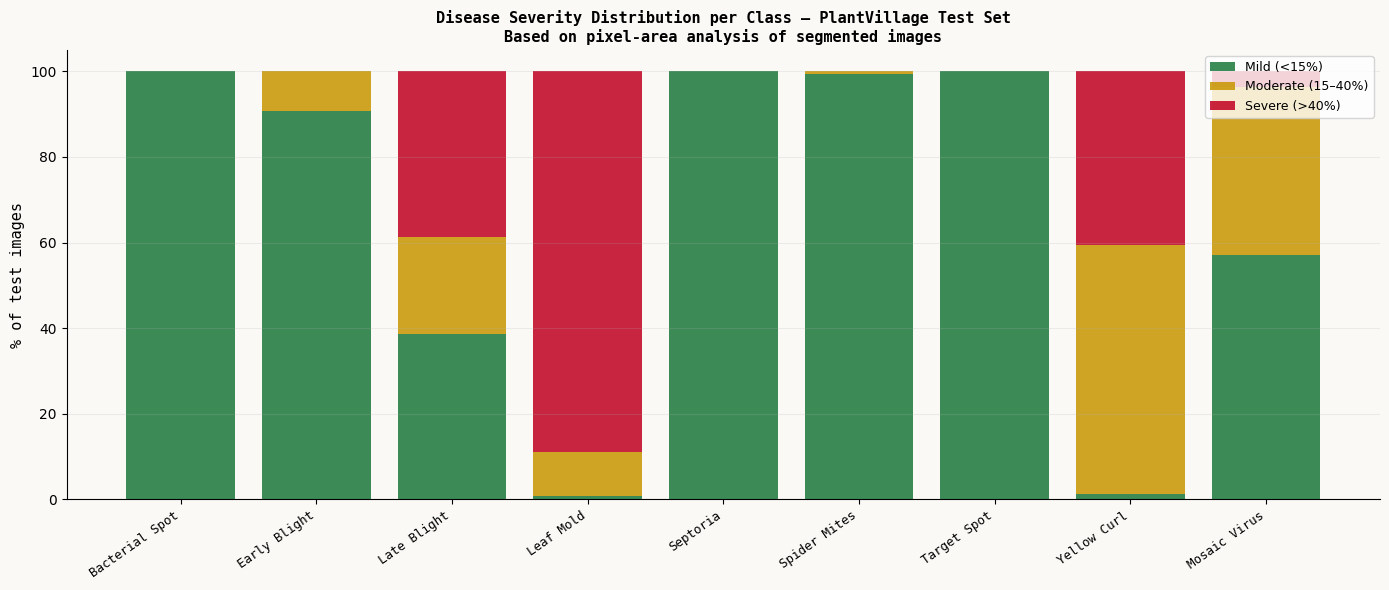

✅ Stacked bar chart saved!


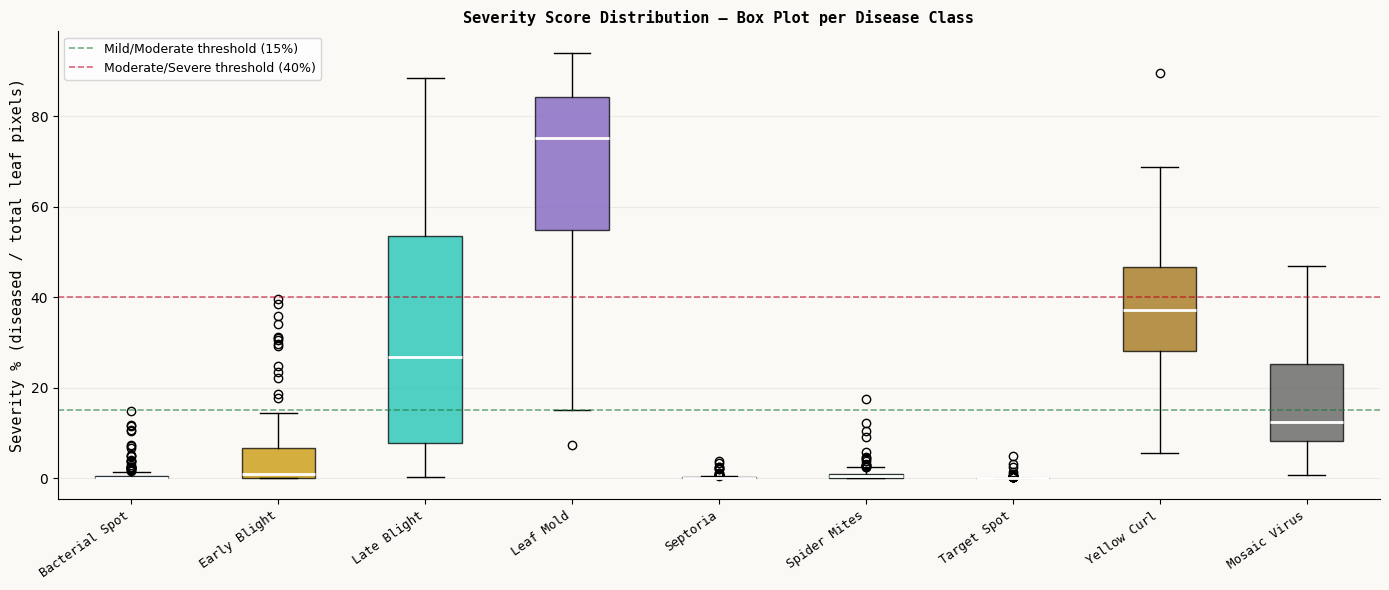

✅ Box plot saved!


In [9]:
# ============================================================
# Cell 8 — Per-Class Severity Distribution Charts
#
# Two figures:
#   Fig 1: Stacked bar chart — Mild / Moderate / Severe
#          breakdown per disease class (main paper figure)
#   Fig 2: Box plot — severity ratio distribution per class
#          (shows spread, outliers, and median)
# ============================================================

disease_classes = [f for f in class_folders if f != 'Tomato___healthy']
display_labels  = [CLASS_DISPLAY.get(f, f) for f in disease_classes]

# ── Figure 1: Stacked bar ────────────────────────────────────
mild_pcts, mod_pcts, sev_pcts = [], [], []
for folder_name in disease_classes:
    cls_df = df[df['class_folder'] == folder_name]
    n = len(cls_df)
    if n == 0:
        mild_pcts.append(0); mod_pcts.append(0); sev_pcts.append(0)
        continue
    mild_pcts.append((cls_df['grade']=='Mild').sum()    / n * 100)
    mod_pcts.append( (cls_df['grade']=='Moderate').sum()/ n * 100)
    sev_pcts.append( (cls_df['grade']=='Severe').sum()  / n * 100)

x = np.arange(len(disease_classes))
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#faf9f6')
ax.set_facecolor('#faf9f6')

b1 = ax.bar(x, mild_pcts, color='#1a783a', label='Mild (<15%)',     alpha=0.85)
b2 = ax.bar(x, mod_pcts,  color='#c89500', label='Moderate (15–40%)', alpha=0.85,
            bottom=mild_pcts)
b3 = ax.bar(x, sev_pcts,  color='#c00020', label='Severe (>40%)',   alpha=0.85,
            bottom=[m+mo for m,mo in zip(mild_pcts,mod_pcts)])

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=35, ha='right',
                   fontfamily='monospace', fontsize=9)
ax.set_ylabel('% of test images', fontsize=11, fontfamily='monospace')
ax.set_title(
    'Disease Severity Distribution per Class — PlantVillage Test Set\n'
    'Based on pixel-area analysis of segmented images',
    fontsize=11, fontweight='bold', fontfamily='monospace'
)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim([0, 105])
ax.grid(axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'severity_distribution_stacked.png'),
            dpi=150, bbox_inches='tight', facecolor='#faf9f6')
plt.show()
print('✅ Stacked bar chart saved!')

# ── Figure 2: Box plot ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#faf9f6')
ax.set_facecolor('#faf9f6')

box_data = [
    df[df['class_folder'] == f]['severity_percent'].values
    for f in disease_classes
]
bp = ax.boxplot(box_data, patch_artist=True, medianprops=dict(color='white', linewidth=2))

colors_box = ['#227c9d','#c89500','#17c3b2','#7c5cbf',
              '#fe6d73','#1a783a','#c00020','#a07010','#5a5a5a']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Threshold lines
ax.axhline(y=15, color='#1a783a', linewidth=1.2, linestyle='--',
           alpha=0.6, label='Mild/Moderate threshold (15%)')
ax.axhline(y=40, color='#c00020', linewidth=1.2, linestyle='--',
           alpha=0.6, label='Moderate/Severe threshold (40%)')

ax.set_xticks(range(1, len(disease_classes)+1))
ax.set_xticklabels(display_labels, rotation=35, ha='right',
                   fontfamily='monospace', fontsize=9)
ax.set_ylabel('Severity % (diseased / total leaf pixels)',
              fontsize=11, fontfamily='monospace')
ax.set_title(
    'Severity Score Distribution — Box Plot per Disease Class',
    fontsize=11, fontweight='bold', fontfamily='monospace'
)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'severity_distribution_boxplot.png'),
            dpi=150, bbox_inches='tight', facecolor='#faf9f6')
plt.show()
print('✅ Box plot saved!')

In [10]:
# ============================================================
# Cell 9 — Combined Classifier + Severity Output
#
# This cell demonstrates the full diagnostic pipeline:
#   1. Load a leaf image
#   2. Run the classifier (Strategy E) → get disease class
#   3. Run the severity estimator → get grade
#   4. Combine into a single diagnostic output string
#
# Output format:
#   "Early Blight — Moderate — 34% of leaf affected"
#
# This is what a real-world deployment would produce.
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image

# Load Strategy E model
model_e_path = os.path.join(
    r'D:\Development\8th Sem Project\TomatoClassification\models',
    'model_E_selective_final.h5'
)
model_e = load_model(model_e_path)
print(f'✅ Strategy E model loaded')

# We need the class index → folder name mapping
# Build from the segmented test set (same folder structure)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
tmp_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_split, target_size=(224,224), batch_size=1,
    class_mode='categorical', shuffle=False
)
# Invert: {int_index: folder_name}
IDX_TO_FOLDER = {v: k for k, v in tmp_gen.class_indices.items()}


def full_diagnosis(color_img_path, seg_img_path):
    """
    Produces a full diagnosis by combining classification and severity.

    Args:
        color_img_path : path to the colour image (for classification)
        seg_img_path   : path to the segmented image (for severity)

    Returns:
        dict with disease_name, confidence, severity_percent, grade,
             and a single formatted diagnosis string
    """
    # Step 1: Classify with Strategy E
    img = keras_image.load_img(color_img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds       = model_e.predict(img_array, verbose=0)
    pred_idx    = int(np.argmax(preds[0]))
    confidence  = float(preds[0][pred_idx])
    folder_name = IDX_TO_FOLDER.get(pred_idx, 'Unknown')
    disease_name = CLASS_DISPLAY.get(folder_name, folder_name)

    # Step 2: Estimate severity on the segmented image
    sev = estimate_severity(seg_img_path, folder_name)

    # Step 3: Combine into diagnosis
    diagnosis = (
        f'{disease_name} — {sev["grade"]} '
        f'({sev["percent"]:.1f}% of leaf affected) '
        f'[confidence: {confidence:.1%}]'
    )

    return {
        'disease_name':     disease_name,
        'confidence':       confidence,
        'severity_percent': sev['percent'],
        'severity_ratio':   sev['ratio'],
        'grade':            sev['grade'],
        'diagnosis':        diagnosis,
    }


# ── Demo: run on 2 images per focus disease ──────────────────
COLOR_TEST = os.path.join(
    r'D:\Development\8th Sem Project\TomatoClassification\dataset\processed',
    'test'
)
DEMO_CLASSES = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Spider_mites Two-spotted_spider_mite',
]

print('\n🌿 Full Diagnosis Demo\n')
print('=' * 75)

for folder_name in DEMO_CLASSES:
    color_folder = os.path.join(COLOR_TEST, folder_name)
    seg_folder   = os.path.join(test_split, folder_name)

    if not os.path.exists(color_folder) or not os.path.exists(seg_folder):
        print(f'⚠️  Skipping {folder_name} — folder not found')
        continue

    color_imgs = sorted([f for f in os.listdir(color_folder)
                         if f.lower().endswith(('.jpg','.jpeg','.png'))])
    seg_imgs   = sorted([f for f in os.listdir(seg_folder)
                         if f.lower().endswith(('.jpg','.jpeg','.png'))])

    # Demo on 2 images per class
    for i in range(min(2, len(color_imgs))):
        c_path = os.path.join(color_folder, color_imgs[i])
        s_path = os.path.join(seg_folder,   seg_imgs[i])

        result = full_diagnosis(c_path, s_path)
        grade_color = {'Mild':'🟢','Moderate':'🟡','Severe':'🔴'}.get(result['grade'],'⚪')
        print(f'{grade_color} {result["diagnosis"]}')

    print()

print('=' * 75)
print('\n✅ Full diagnosis pipeline working!')

✅ Strategy E model loaded
Found 1399 images belonging to 10 classes.

🌿 Full Diagnosis Demo

🟢 Bacterial Spot — Mild (0.5% of leaf affected) [confidence: 79.1%]
🟢 Bacterial Spot — Mild (0.0% of leaf affected) [confidence: 100.0%]

🟢 Early Blight — Mild (5.2% of leaf affected) [confidence: 95.3%]
🟢 Early Blight — Mild (1.3% of leaf affected) [confidence: 91.0%]

🟢 Target Spot — Mild (0.0% of leaf affected) [confidence: 68.6%]
🟢 Target Spot — Mild (0.0% of leaf affected) [confidence: 60.8%]


✅ Full diagnosis pipeline working!


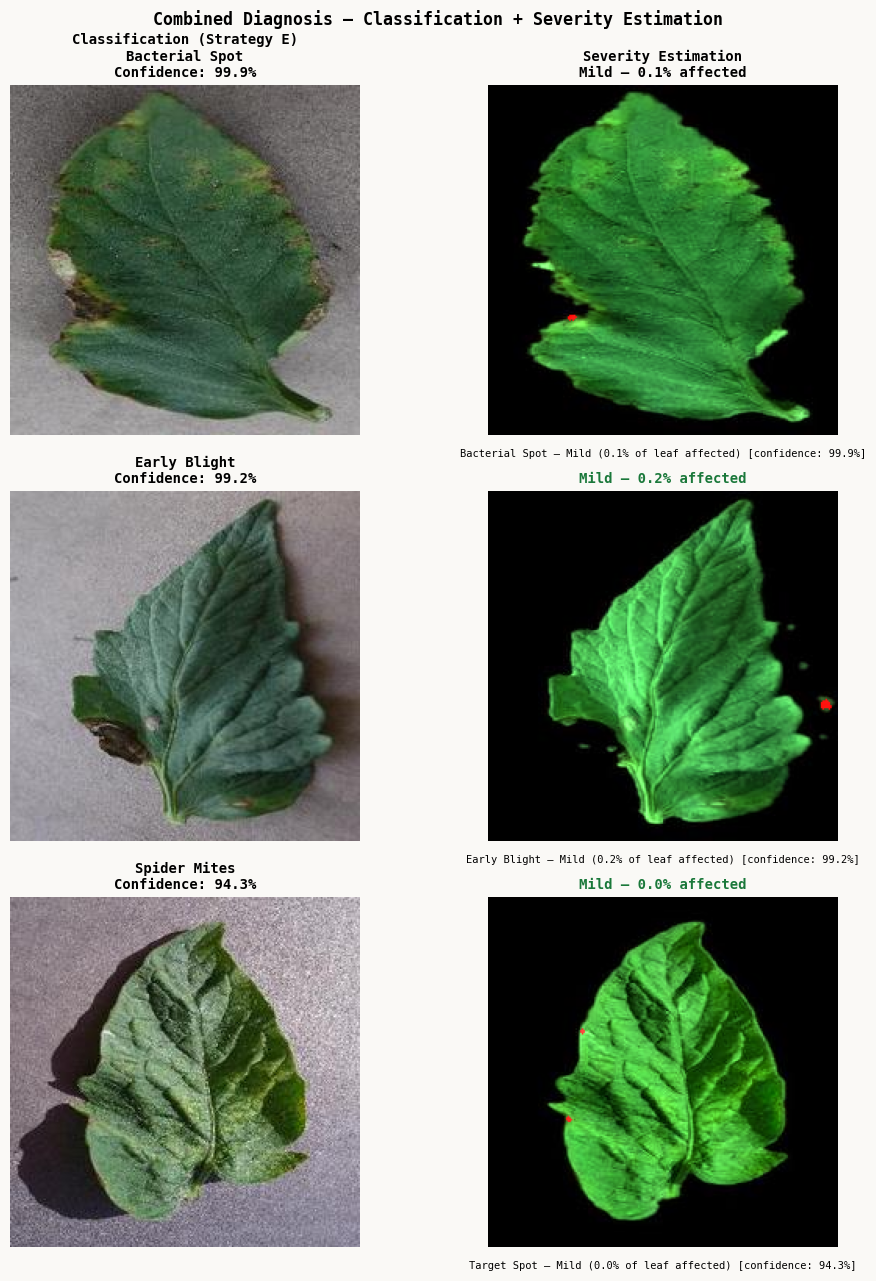

✅ Combined diagnosis figure saved!


In [13]:
# ============================================================
# Cell 10 — Visual Demo: Combined Diagnosis on 3 Leaf Images
#
# Shows a 2-column figure for each demo image:
#   Left:  original colour image with classification label
#   Right: severity overlay with grade and percent
#
# This is the figure for the paper's practical application
# section — shows what a farmer would actually see.
# ============================================================

DEMO_DISPLAY = {
    'Tomato___Bacterial_spot':                         'Bacterial Spot',
    'Tomato___Early_blight':                           'Early Blight',
    'Tomato___Spider_mites Two-spotted_spider_mite':   'Spider Mites',
}

fig, axes = plt.subplots(3, 2, figsize=(10, 13))
fig.patch.set_facecolor('#faf9f6')
fig.suptitle(
    'Combined Diagnosis — Classification + Severity Estimation',
    fontsize=12, fontweight='bold', fontfamily='monospace'
)

grade_palette = {'Mild': '#1a783a', 'Moderate': '#c89500', 'Severe': '#c00020'}

for row, (folder_name, display_name) in enumerate(DEMO_DISPLAY.items()):
    color_folder = os.path.join(COLOR_TEST, folder_name)
    seg_folder   = os.path.join(test_split, folder_name)

    color_imgs = sorted([f for f in os.listdir(color_folder)
                         if f.lower().endswith(('.jpg','.jpeg','.png'))])
    seg_imgs   = sorted([f for f in os.listdir(seg_folder)
                         if f.lower().endswith(('.jpg','.jpeg','.png'))])

    # Use image index 3 for visual variety
    idx = min(3, len(color_imgs)-1)
    c_path = os.path.join(color_folder, color_imgs[idx])
    s_path = os.path.join(seg_folder,   seg_imgs[idx])

    result  = full_diagnosis(c_path, s_path)
    seg_bgr = cv2.imread(s_path)
    seg_rgb = cv2.cvtColor(seg_bgr, cv2.COLOR_BGR2RGB)
    seg_hsv = cv2.cvtColor(seg_bgr, cv2.COLOR_BGR2HSV)
    col_rgb = np.array(keras_image.load_img(c_path, target_size=(224,224)))

    # Build severity overlay
    _, _, v_ch = cv2.split(seg_hsv)
    leaf_m = cv2.morphologyEx((v_ch>20).astype(np.uint8)*255,
                               cv2.MORPH_CLOSE,
                               cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)))
    hsv_ranges = DISEASE_HSV.get(folder_name,[])
    dis_m = np.zeros(seg_hsv.shape[:2], dtype=np.uint8)
    for lo, hi in hsv_ranges:
        dis_m = cv2.bitwise_or(dis_m, cv2.inRange(seg_hsv, lo, hi))
    dis_m = cv2.bitwise_and(dis_m, leaf_m)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
    dis_m = cv2.morphologyEx(cv2.morphologyEx(dis_m, cv2.MORPH_OPEN, k), cv2.MORPH_CLOSE, k)

    ov = seg_rgb.astype(float)
    hl = cv2.bitwise_and(leaf_m, cv2.bitwise_not(dis_m))
    ov[hl>0,1]   = np.clip(ov[hl>0,1]*1.3,0,255)
    ov[hl>0,0]   = ov[hl>0,0]*0.7
    ov[hl>0,2]   = ov[hl>0,2]*0.7
    ov[dis_m>0,0]= 255
    ov[dis_m>0,1]= ov[dis_m>0,1]*0.3
    ov[dis_m>0,2]= ov[dis_m>0,2]*0.3
    ov = ov.astype(np.uint8)

    grade_c = grade_palette.get(result['grade'], '#181717')

    # Left: colour + classification
    axes[row, 0].imshow(col_rgb)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(
        f'{display_name}\nConfidence: {result["confidence"]:.1%}',
        fontsize=10, fontweight='bold', fontfamily='monospace'
    )

    # Right: severity overlay
    axes[row, 1].imshow(ov)
    axes[row, 1].axis('off')
    axes[row, 1].set_title(
        f'{result["grade"]} — {result["severity_percent"]:.1f}% affected',
        fontsize=10, fontweight='bold', fontfamily='monospace',
        color=grade_c
    )

    # Full diagnosis text below
    axes[row, 1].text(
        0.5, -0.04, result['diagnosis'],
        transform=axes[row,1].transAxes, ha='center', va='top',
        fontsize=7.5, fontfamily='monospace', wrap=True
    )

# Column labels
# Column labels
axes[0,0].set_title('Classification (Strategy E)\n' + axes[0,0].get_title(),
                    fontsize=10, fontweight='bold', fontfamily='monospace')
axes[0,1].set_title('Severity Estimation\n' + axes[0,1].get_title(),
                    fontsize=10, fontweight='bold', fontfamily='monospace', color='k')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'severity_combined_diagnosis.png'),
            dpi=150, bbox_inches='tight', facecolor='#faf9f6')
plt.show()
print('✅ Combined diagnosis figure saved!')

In [14]:
# ============================================================
# Cell 11 — Save All Outputs & Final Summary
# ============================================================

print(f'📁 All outputs saved to: {OUTPUT_DIR}\n')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, fname)) / 1024
    print(f'   {fname}  ({size:.0f} KB)')

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Severity Estimator complete!

  Outputs:
    severity_results.csv           — raw data, all images
    severity_distribution_stacked  — main paper figure
    severity_distribution_boxplot  — supplementary figure
    severity_mask_verification     — method validation
    severity_combined_diagnosis    — practical demo figure

  Next steps:
    → 08_robustness_testing.ipynb
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

📁 All outputs saved to: D:\Development\8th Sem Project\TomatoClassification\outputs\severity

   severity_combined_diagnosis.png  (1629 KB)
   severity_distribution_boxplot.png  (101 KB)
   severity_distribution_stacked.png  (87 KB)
   severity_mask_verification.png  (971 KB)
   severity_results.csv  (189 KB)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Severity Estimator complete!

  Outputs:
    severity_results.csv           — raw data, all images
    severity_distribution_stacked  — main paper figure
    severity_distribution_boxplot  — supplementary figure
    severity_mask_verification     — method validation
    severity_combined_diagnosis    — practical demo figure

  Next steps:
    → 08_robustness_testing.ipynb
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

